In [1]:
# Imports

In [2]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import pytesseract
import easyocr

In [3]:
# Add this after imports — required on Windows

In [4]:
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [5]:
#  Where screenshots are store

In [6]:

SCREENSHOT_DIR = r"E:\Project Demo\screenshots"

TEST_IMAGES = [
    "Test1.jpeg",
    "Test2.jpeg",
    "Test3.jpeg",
    "Test4.jpeg",
]

In [7]:
#  Verify image loads correctly

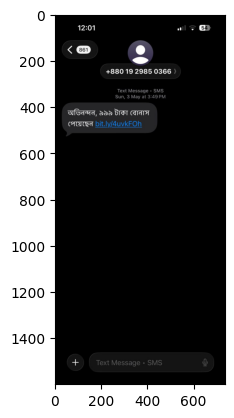

In [8]:
img = cv2.imread(
    os.path.join(
        SCREENSHOT_DIR,
        TEST_IMAGES[0]
    )
)

plt.imshow(
    cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
)
plt.show()

In [9]:
# Improve OCR quality

In [10]:
def preprocess_image(path):

    img = cv2.imread(path)

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    gray = cv2.resize(
        gray,
        None,
        fx=2,
        fy=2
    )

    return gray

In [11]:
#  Visual inspection

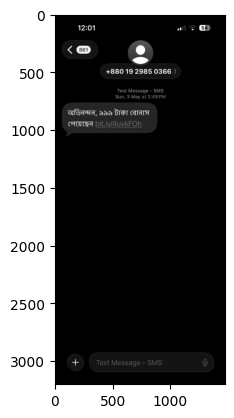

In [12]:
processed = preprocess_image(
    os.path.join(
        SCREENSHOT_DIR,
        TEST_IMAGES[0]
    )
)

plt.imshow(
    processed,
    cmap="gray"
)
plt.show()

In [13]:
#  Image -> Text 
# (Tesseract OCR)


In [14]:
def run_tesseract(path):

    img = preprocess_image(path)

    text = pytesseract.image_to_string(
        img,
        lang="eng+ben"
    )

    return text

In [15]:
#  Verify OCR works

In [16]:
text = run_tesseract(
    os.path.join(
        SCREENSHOT_DIR,
        TEST_IMAGES[0]
    )
)

print(text)

12:01 of

€ &D *
aj
+880 19 2985 0366

Text Message * SMS
Sun, 3 May at 3:49PM

অভিনন্দন, ৯৯৯ টাকা বোনাস
পেয়েছেন bit.ly/4uvkKFOh



In [17]:
# EasyOCR Initialization

In [18]:
reader = easyocr.Reader(['en', 'bn'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [19]:
# Image -> Text
# (EasyOCR)

In [20]:
def run_paddle(path):
    result = reader.readtext(path)
    texts = [item[1] for item in result]
    return " ".join(texts)

In [21]:
# Test EasyOCR

In [22]:
text = run_paddle(
    os.path.join(
        SCREENSHOT_DIR,
        TEST_IMAGES[0]
    )
)

print(text)

e:\Project Demo\venv311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


12:01 861 +880 19 2985 0366 Text Message SMS Sun, 3 May at 3:49 PM অভিনন্দন, ৯৯৯ টাকা বোনাস পেয়েছেন bitlylAuvkFOh Text Message SMS 9


In [23]:
# OCR Comparison

In [24]:
for img_name in TEST_IMAGES:

    path = os.path.join(
        SCREENSHOT_DIR,
        img_name
    )

    tess = run_tesseract(path)

    paddle = run_paddle(path)

    print("="*60)
    print(img_name)
    print()

    print("Tesseract:")
    print(tess)

    print()

    print("EasyOCR:")
    print(paddle)

e:\Project Demo\venv311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test1.jpeg

Tesseract:
12:01 of

€ &D *
aj
+880 19 2985 0366

Text Message * SMS
Sun, 3 May at 3:49PM

অভিনন্দন, ৯৯৯ টাকা বোনাস
পেয়েছেন bit.ly/4uvkKFOh


EasyOCR:
12:01 861 +880 19 2985 0366 Text Message SMS Sun, 3 May at 3:49 PM অভিনন্দন, ৯৯৯ টাকা বোনাস পেয়েছেন bitlylAuvkFOh Text Message SMS 9


e:\Project Demo\venv311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test2.jpeg

Tesseract:
12:01 of
১547, *
@j>>
Orange Club

Text Message - SMS

Wed, 4 Feb at 10:47AM
Dear Customer, your Orange
Club status has been upgraded
to GOLD. For details visit MyBL
App (https://mybl.digital/Vtcn) or
dial 1167



EasyOCR:
12:01 847 Orange club Text Message SMS Wed; 4 Feb at 10:47AM Dear Customer your Orange Club status has been upgraded to GOLD. For details visit MyBL (https:llmybl.digitallVtcn) or dial *121*6# Text Message SMS 9 App


e:\Project Demo\venv311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test3.jpeg

Tesseract:
11:59 of

< & *
aj
+880 14 0760 3227

Text Message * SMS
Monday 2:11PM

Your & 2,110 bonus in account!
Withdraw cash now:https://dit.\y/
3SdqLvi

)


EasyOCR:
11:59 862 +880 14 0760 3227 Text Message SMS Monday 2:11PM Your ৮2,110 bonus in account! Withdraw cash now:https:llbit.lyl 3Sdg_Vi Text Message SMS 9


e:\Project Demo\venv311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test4.jpeg

Tesseract:
12:55
< & *
>
BL Courses
Text Message * SMS
Yesterday 11:24AM
এগিয়ে faa MyBL আাপে আপক্কিল

করুন। ভিজিট করুন: 1711)5://
tinyurl.com/39x748hk



EasyOCR:
12:55 769 BL Courses Text Message SMS Yesterday 11:24 AM ইংরেজি, আরবি ও কোরিয়ান ভাষায় দক্ষতা অর্জন করে নিজের ক্যারিয়ারকে এগিয়ে নিন MyBL অ্যাপে আপস্কিল করুন | ভিজিট করুন: https:ll tinyurl com/39x748hk Text Message SMS 9


In [25]:
# Best OCR output

In [26]:
def extract_text(path):

    tess = run_tesseract(path)

    paddle = run_paddle(path)

    if len(paddle) > len(tess):
        return paddle

    return tess

In [27]:
# Screenshot
# ↓
# OCR
# ↓
# Final Text

In [28]:
for img_name in TEST_IMAGES:

    path = os.path.join(
        SCREENSHOT_DIR,
        img_name
    )

    text = extract_text(path)

    print("="*60)
    print(img_name)
    print(text)

e:\Project Demo\venv311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test1.jpeg
12:01 861 +880 19 2985 0366 Text Message SMS Sun, 3 May at 3:49 PM অভিনন্দন, ৯৯৯ টাকা বোনাস পেয়েছেন bitlylAuvkFOh Text Message SMS 9


e:\Project Demo\venv311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test2.jpeg
12:01 847 Orange club Text Message SMS Wed; 4 Feb at 10:47AM Dear Customer your Orange Club status has been upgraded to GOLD. For details visit MyBL (https:llmybl.digitallVtcn) or dial *121*6# Text Message SMS 9 App


e:\Project Demo\venv311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test3.jpeg
11:59 862 +880 14 0760 3227 Text Message SMS Monday 2:11PM Your ৮2,110 bonus in account! Withdraw cash now:https:llbit.lyl 3Sdg_Vi Text Message SMS 9


e:\Project Demo\venv311\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test4.jpeg
12:55 769 BL Courses Text Message SMS Yesterday 11:24 AM ইংরেজি, আরবি ও কোরিয়ান ভাষায় দক্ষতা অর্জন করে নিজের ক্যারিয়ারকে এগিয়ে নিন MyBL অ্যাপে আপস্কিল করুন | ভিজিট করুন: https:ll tinyurl com/39x748hk Text Message SMS 9
